In [ ]:
import os
import sys
import time
import json
import random
import argparse
from pathlib import Path

import torch

# Repo setup
repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from argparse import Namespace
from pathlib import Path
import torch

from revlm.config_utils import configure_args
from revlm.run.edit import run_edit

editor_name = "ike_chain"
model_name = "qwen3_4b"       # <-- change to match your model
dataset_name = "aokvqa"        # <-- change to match your dataset


In [ ]:
import shutil

# Map short model names to full HF model names used in results/pred/
MODEL_NAME_MAP = {
    "qwen3": "Qwen3-VL-8B-Instruct",
    "qwen3_4b": "Qwen3-VL-4B-Instruct",
    "llava": "llava-1.5-7b-hf",
    "blip": "instructblip-vicuna-7b",
}

project_root = Path(repo_root)

full_model_name = MODEL_NAME_MAP[model_name]
src = project_root / "results" / "pred" / full_model_name / dataset_name / "mc_all.json"
dst_dir = project_root / "results" / "test" / f"editor_{editor_name}" / model_name / dataset_name
dst_dir.mkdir(parents=True, exist_ok=True)
dst = dst_dir / "pred_mc.json"

assert src.exists(), f"Source not found: {src}"
shutil.copy2(src, dst)
print(f"Copied {src}\n    -> {dst}")


Copied /scratch/jq2uw/MME/instruct_vlm_edit/results/pred/Qwen3-VL-4B-Instruct/aokvqa/mc_all.json
    -> /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa/pred_mc.json


Task evaluation metrics will be saved to /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa
Edit evaluation metrics will be saved to /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa
Predictions will be saved to /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa
Post-edit predictions will be saved to /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa/pred_postedit
Unified filename to save: mc_all.json
Step 1 (predictions)
Total samples 18195 loaded from /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa/pred_mc.json
getting edits predicted by: label_maxprob

model_old predictions:
{'uid': '1', 'image': 'data/images/aokvqa/train2017/000000299207.jpg', 'question': 'What is the man by the bags awaiting?', 'answer': 'cab', 'rationale': 'A train would not be on the street, he would not have luggage waiting for a delivery, and the sk

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jq2uw/.netrc.
wandb: Currently logged in as: jq2uw (vlm_edit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Batch 1: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1...[Augmenter] Loading Qwen/Qwen2.5-1.5B-Instruct...
[Keys] +4 added, 3 merged (from 7 candidates)
[IKE_CHAIN] +1 edits (p_yes>0.5, merge=True, area=0.9), 0->4 keys, 0.0 MB
Batch 2: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1...[Keys] +8 added, 0 merged (from 8 candidates)
[IKE_CHAIN] +1 edits (p_yes>0.5, merge=True, area=0.9), 4->12 keys, 0.0 MB
Batch 3: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1...[Keys] +8 added, 0 merged (from 8 candidates)
[IKE_CHAIN] +1 edits (p_yes>0.5, merge=True, area=0.9), 12->20 keys, 0.1 MB
Batch 4: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1..

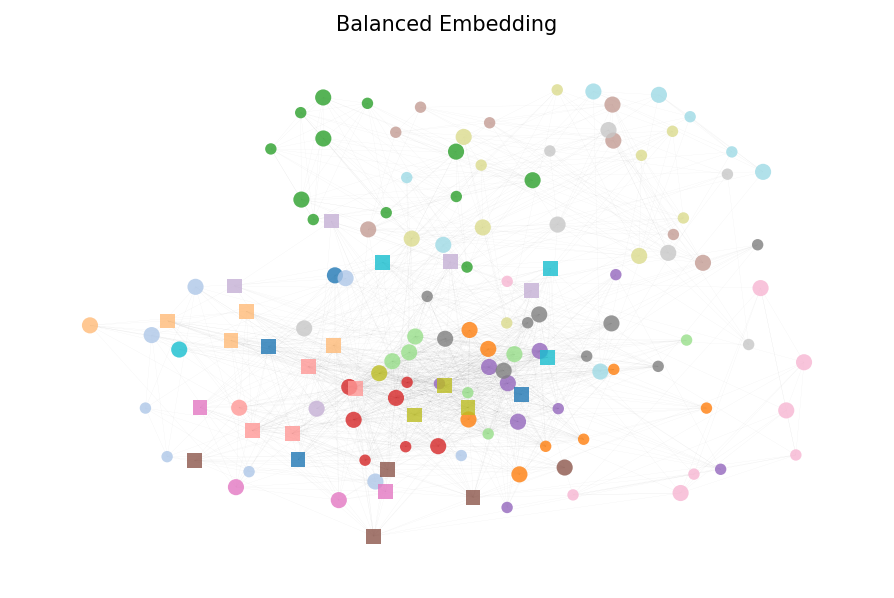

[Timing] reliability: 13.91s
Reliability: 0.9500
[IKE_CHAIN] applied facts to 100/100 examples
  [0] q='What do we call the structures at the head of the bed?' answer='finials' prompt='The tips of bed structures often have a specific design or ornamentation. The answer to 'What is the tip of the bed structures called?' is finials. These ornamental tips are commonly referred to as finials. The image shows bed structures with tips. What do we call the structures at the head of the bed?'
  [1] q='What is the term for the components located at the top of the bed?' answer='finials' prompt='The tips of bed structures often have a specific design or ornamentation. The answer to 'What is the tip of the bed structures called?' is finials. These ornamental tips are commonly referred to as finials. The image shows bed structures with tips. What is the term for the components located at the top of the bed?'
  [2] q='How are the structures at the bed's head referred to?' answer='finials' prompt='Th

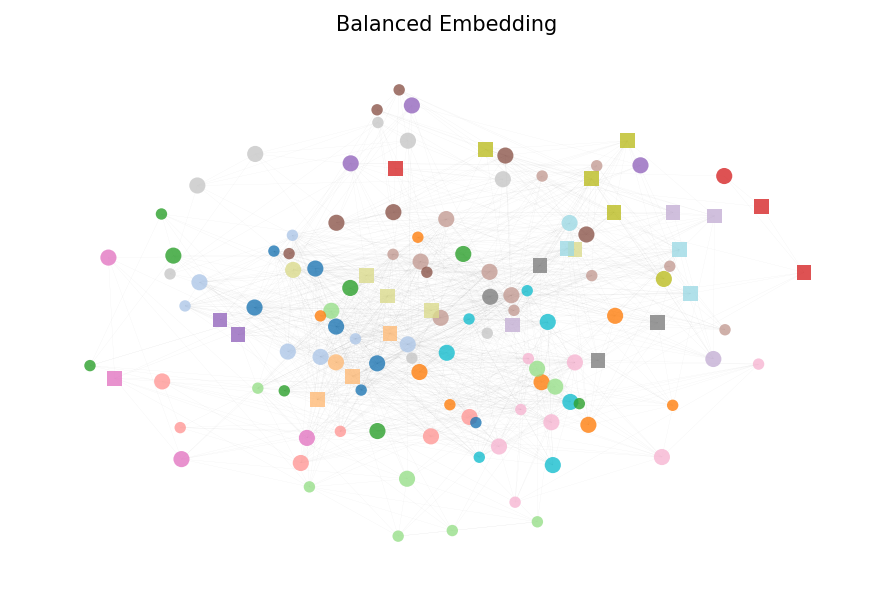

[Timing] reliability: 29.37s
Reliability: 0.9750
[IKE_CHAIN] applied facts to 200/200 examples
  [0] q='What is required to ensure the items in the pink container function properly?' answer='sharpener' prompt='Pencils need to be kept sharp to function properly. The answer to 'What does one need to keep the items in the pink container working?' is sharpener. The image shows a pink container. Cats that live indoors are usually tame. The round things resemble beans in shape and size. A sharpener is used to keep pencils sharp. The pink container holds pencils. What is required to ensure the items in the pink container function properly?'
  [1] q='What must be done to maintain the operation of the items in the pink container?' answer='sharpener' prompt='Pencils need to be kept sharp to function properly. The answer to 'What is the purpose of the colorful bag?' is holding gifts. The answer to 'What does one need to keep the items in the pink container working?' is sharpener. The image shows 

In [ ]:

# Project root
project_root = Path(repo_root)

# Build test paths from args (no hardcoding)
args = Namespace(
    config="revlm/config/config.yaml",
    editor=editor_name,
    model_name=model_name,
    dataset_name=dataset_name,
    task="mc",
    batch_size=1,
    split="all",
    rationale=False,
    cot=False,
    subsample=0,
    subsample_edits=500,
    overwrite=True,
)

# Derive result prefix from args
res_prefix = project_root / "results" / "test" / f"editor_{args.editor}" / args.model_name / args.dataset_name
res_prefix.mkdir(parents=True, exist_ok=True)
(res_prefix / "pred_postedit").mkdir(parents=True, exist_ok=True)

# Force all outputs into the test prefix (overwrite allowed)
args.task_dir = str(res_prefix)
args.edit_dir = str(res_prefix)
args.pred_dir = str(res_prefix)
args.pred_path = str(res_prefix / "pred_mc.json")

args.pred_postedit_dir = str(res_prefix / f"pred_postedit")

args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
args.suffix = "_cot" if args.rationale and args.cot else ("_rationale" if args.rationale else "")

config = configure_args(args, config_path=args.config)
config.subsample = args.subsample
config.subsample_edits = args.subsample_edits
config.rationale = args.rationale
config.cot = args.cot
config.pred_path = args.pred_path
config.overwrite = args.overwrite
config.task_dir = args.task_dir
config.pred_dir = args.pred_dir
config.pred_postedit_dir = args.pred_postedit_dir
config.edit_dir = args.edit_dir

config.plot_k_dist = True 
run_edit(config, sequential=True, eval_every=20)